### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P371 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

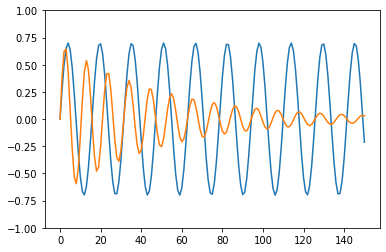

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 10

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

371

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.000680070235183169   1.5250604152679443 sec       
199: 0.0002571979484611246   2.178532600402832 sec        
299: 0.00010099481078627567   2.9315857887268066 sec      
399: 0.000299427416963289   3.7962677478790283 sec        
499: 0.0001011805738400251   4.655666351318359 sec        
599: 7.713876372612305e-05   5.384661436080933 sec       
699: 6.616161737030006e-05   6.071466445922852 sec       
799: 7.65988462704107e-05   6.9378981590271 sec           
899: 5.608377939732027e-05   7.665873289108276 sec        
999: 5.021013775287609e-05   8.476542472839355 sec       
1099: 0.0001188216259295544   9.211796283721924 sec       
1199: 5.292052288183048e-05   9.974638223648071 sec       
1299: 4.483909010958717e-05   10.690016031265259 sec       
1399: 4.001990454258935e-05   11.466676712036133 sec       
1499: 3.729599990906328e-05   12.278961658477783 sec       
1599: 5.784068902153235e-05   13.02741551399231 sec        
1699: 4.100087704163083e-05   13.68547

26399: 3.591163765365503e-05   228.75135278701782 sec       
26499: 3.4675267289458554e-05   229.92929887771606 sec      
26599: 3.4196608715949204e-05   230.92825031280518 sec      
26699: 8.337278716749025e-05   231.89560675621033 sec       
26799: 3.532780933899277e-05   232.9535801410675 sec        
26899: 3.440595722231966e-05   233.94321990013123 sec       
learning rate: 0.05
26999: 0.00015973892086413192   235.0964937210083 sec       
27099: 8.04966610288273e-05   236.14287996292114 sec        
27199: 6.21845559147066e-05   237.143235206604 sec         
learning rate: 0.025
27299: 4.3356929751814054e-05   238.19210052490234 sec      
27399: 3.6682199303680254e-05   239.2602686882019 sec       
27499: 3.52894288440559e-05   240.1960699558258 sec         
27599: 3.459783024227905e-05   241.20569133758545 sec       
27699: 3.4178652247993785e-05   242.25507831573486 sec      
27799: 3.390060177512358e-05   243.60921263694763 sec       
27899: 3.3710710042033756e-05   244.719948530

52799: 0.020311285296171572   560.2048234939575 sec      
52899: 0.019781950563984997   561.6266407966614 sec      
52999: 0.019253157560469015   562.9891095161438 sec      
53099: 0.01956179310296754   564.4290583133698 sec       
53199: 0.018240696924058317   565.7819440364838 sec      
53299: 0.01940613018967311   567.0536239147186 sec       
53399: 0.017266593430511044   568.2983782291412 sec      
53499: 0.016795815892332616   570.1836965084076 sec      
53599: 0.016366846008017903   572.5231363773346 sec      
53699: 0.015878926555441573   573.9320454597473 sec      
53799: 0.01557672172251412   575.280868768692 sec        
53899: 0.015089583630746502   576.6220271587372 sec      
53999: 0.014898921739886682   578.0627875328064 sec      
54099: 0.014317334779023227   579.424830198288 sec       
54199: 0.015053861698783429   580.7411801815033 sec      
54299: 0.013555145312511648   582.1148154735565 sec      
54399: 0.012927766731354555   583.4251656532288 sec      
54499: 0.01250

79499: 0.001197586952261344   913.7023181915283 sec        
79599: 6.50608559418147e-05   914.9566025733948 sec        
79699: 3.590323253174366e-05   916.1839716434479 sec       
learning rate: 0.1
79799: 0.00023799532410097188   917.4361975193024 sec      
79899: 0.00013536409050526253   918.6640965938568 sec      
79999: 9.664296232487764e-05   919.9054081439972 sec       
learning rate: 0.05
80099: 7.217615869073822e-05   921.1848468780518 sec       
80199: 4.3664244696529634e-05   922.4373173713684 sec      
80299: 3.742958140077186e-05   923.6868195533752 sec       
80399: 3.5363526588353204e-05   925.0264370441437 sec      
80499: 3.4487430014656475e-05   926.2952060699463 sec      
80599: 3.405081092214439e-05   927.5582749843597 sec       
80699: 3.3791979096382145e-05   928.8394179344177 sec      
80799: 3.362133144057591e-05   930.0355849266052 sec       
80899: 3.350240246405454e-05   931.2576489448547 sec       
learning rate: 0.2
80999: 0.00027301819313345864   932.615112

105999: 0.0012163452679828264   1249.3994431495667 sec       
106099: 4.805003830190236e-05   1250.754296541214 sec        
106199: 0.00024025699250028324   1252.025140285492 sec       
106299: 4.536567347456916e-05   1253.3154575824738 sec       
106399: 5.7923716688992896e-05   1254.6590416431427 sec      
106499: 4.30527251095989e-05   1256.0487558841705 sec        
106599: 4.318461312475182e-05   1257.352567434311 sec        
106699: 9.082253797882152e-05   1258.6173470020294 sec       
106799: 6.449383533131015e-05   1259.8978176116943 sec       
learning rate: 0.05
106899: 0.00017469873016407212   1261.1843416690826 sec      
learning rate: 0.025
106999: 4.252958366643898e-05   1262.567721605301 sec        
107099: 3.6869262566462485e-05   1263.8194372653961 sec      
107199: 3.5246804594580246e-05   1265.1496868133545 sec      
107299: 3.4391920352701477e-05   1266.423103094101 sec       
107399: 3.3848322489301036e-05   1267.7196094989777 sec      
107499: 3.355803076871399e-05

132099: 8.165684532215035e-05   1633.3442785739899 sec       
132199: 5.29963837073794e-05   1634.8809657096863 sec        
132299: 6.829663750595612e-05   1636.4162998199463 sec       
132399: 6.009439121792949e-05   1637.8984026908875 sec       
132499: 4.64950409053475e-05   1639.4319067001343 sec        
132599: 4.341590351006991e-05   1640.9107451438904 sec       
132699: 3.826442649281594e-05   1642.428535938263 sec        
132799: 3.695534790143882e-05   1643.977677822113 sec        
132899: 3.563929226062249e-05   1645.5366530418396 sec       
132999: 3.8435887283135684e-05   1647.0141615867615 sec      
133099: 3.5114318540064764e-05   1648.5282731056213 sec      
133199: 0.00011758881360907914   1650.076822757721 sec       
133299: 3.948234506908698e-05   1651.5857565402985 sec       
133399: 0.0003054334010633796   1653.1178405284882 sec       
learning rate: 0.1
133499: 0.00030298620741521975   1654.6637887954712 sec      
133599: 0.00014893349829161933   1656.1474270820618

157699: 0.004109013889866805   1988.395869255066 sec        
157799: 0.0035718338537123417   1989.707419872284 sec       
157899: 0.10265641767969882   1991.1080729961395 sec        
157999: 0.002779335715554924   1992.7421000003815 sec       
158099: 0.002450667433858538   1994.0748662948608 sec       
158199: 0.002178618295005146   1995.5193326473236 sec       
158299: 0.001956501684033179   1996.896380662918 sec        
158399: 0.00181179391820242   1998.2650334835052 sec        
158499: 0.0016601788347503411   1999.6321313381195 sec      
158599: 0.001537359677341973   2001.0500347614288 sec       
158699: 0.0014347163298539028   2002.4442992210388 sec      
158799: 0.005822988254474237   2003.8094301223755 sec       
158899: 0.0013013396531771188   2005.2067301273346 sec      
158999: 0.0012287758229380867   2006.5578651428223 sec      
159099: 0.0011662642892378572   2007.9007551670074 sec      
159199: 0.0011110368286902411   2009.2632296085358 sec      
159299: 0.00133290301515

183499: 5.229109964616181e-05   2365.7713396549225 sec       
183599: 4.981442610588451e-05   2367.1732227802277 sec       
183699: 4.7559194968207835e-05   2368.688599586487 sec       
183799: 4.552720276177308e-05   2370.160064458847 sec        
183899: 4.370958191353311e-05   2371.6294322013855 sec       
183999: 4.209182716268946e-05   2373.139484643936 sec        
184099: 4.066112498587283e-05   2374.6810150146484 sec       
184199: 3.9408552572528274e-05   2376.1148607730865 sec      
184299: 3.832607964218544e-05   2377.5096518993378 sec       
184399: 3.740286646694262e-05   2378.9950942993164 sec       
184499: 3.6624347585228666e-05   2380.46874666214 sec        
184599: 3.981408696911447e-05   2381.933965444565 sec        
184699: 3.7466341938828946e-05   2383.3925421237946 sec      
184799: 3.6372858470534063e-05   2384.835671186447 sec       
184899: 3.5614944576475144e-05   2386.300515651703 sec       
184999: 3.505220517599575e-05   2387.735852241516 sec        
185099: 

208999: 3.437339943767233e-05   2723.6207296848297 sec       
209099: 3.4022112547500955e-05   2725.0439882278442 sec      
209199: 0.009846739872889112   2726.3745667934418 sec        
209299: 4.2272949891082374e-05   2727.7126882076263 sec      
209399: 3.72588249232964e-05   2729.1402311325073 sec        
learning rate: 0.1
209499: 0.00048418704942008897   2730.484770298004 sec       
209599: 0.000241525214692036   2731.829441547394 sec         
209699: 0.00019142981919645954   2733.2713627815247 sec      
learning rate: 0.05
209799: 0.000365383796464851   2734.671830177307 sec         
209899: 0.000206012598491   2735.996624469757 sec            
209999: 0.0001169564387600064   2737.3218586444855 sec       
210099: 5.5900558377131516e-05   2738.630290031433 sec       
210199: 4.256769602083123e-05   2739.9525139331818 sec       
210299: 3.803359153198441e-05   2741.33891749382 sec         
210399: 3.592138854481898e-05   2742.721121788025 sec        
210499: 3.478260146376367e-05  

In [23]:
minLoss

Array(3.30810266e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

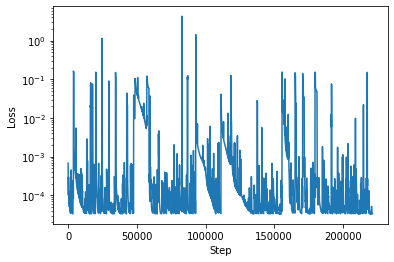

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

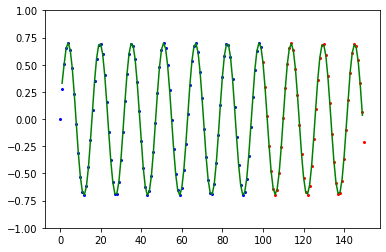

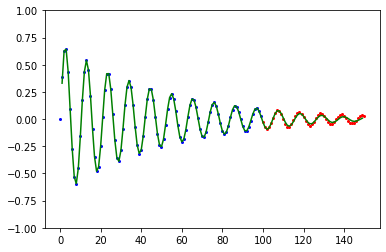

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

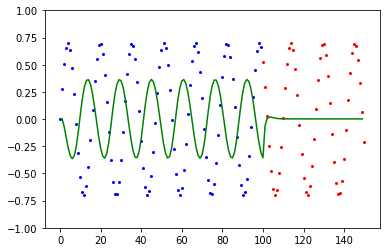

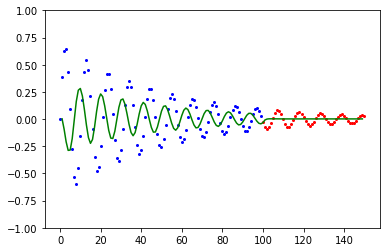

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[45400,
 Array(3.35310649e-05, dtype=float64),
 Array(2.79607952e-05, dtype=float64),
 [((Array([[ 1.32922141, -0.13154276,  1.5954262 , -1.47124497, -2.64703464,
             0.62964721, -0.50770457,  0.70653086, -2.03218449,  0.17330788]],      dtype=float64),
    Array([[ 2.24624269, -1.58858416, -1.9612054 ,  2.59174071, -1.59596753,
            -0.4379176 , -1.81941351,  1.88838293,  0.47087452, -0.98823189],
           [ 0.77702593, -0.86680302,  0.45523895, -0.61484641, -0.98437989,
             0.39832964,  2.27183105, -1.66457073, -2.69373845, -2.89305689],
           [ 1.0638923 , -2.41597226, -0.75605953, -1.38603754, -0.63946175,
             1.08147518, -1.91335703, -3.18265581,  2.14693539, -0.51038254],
           [-0.49819809, -0.12186439, -0.63322855,  1.05499057,  1.19615652,
            -1.01576464,  0.38523935,  2.16807032, -1.62130228, -0.02070422],
           [-1.48268496, -0.41798647,  0.47286226,  0.73039768, -0.28685754,
             0.88372616,  1.04332263,  1

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

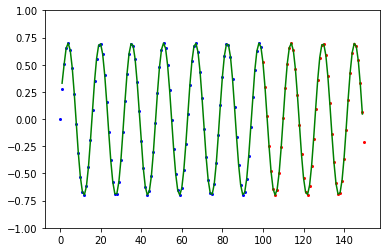

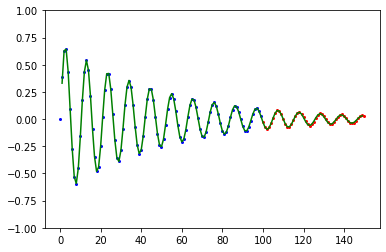

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [45400, Array(3.35310649e-05, dtype=float64), Array(2.79607952e-05, dtype=float64)]
3600 3.322795613459701e-05 8.178789950230093e-05


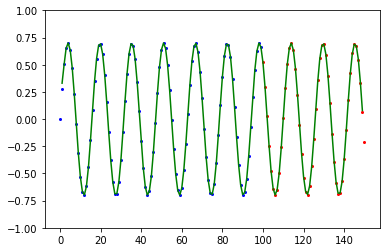

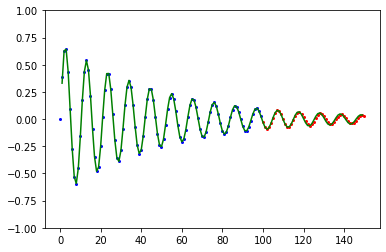

13500 3.4214083548605325e-05 0.0015400729427189862


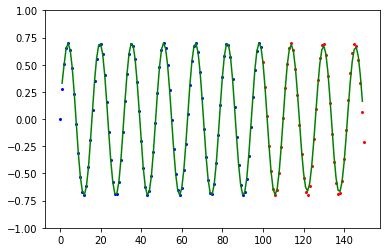

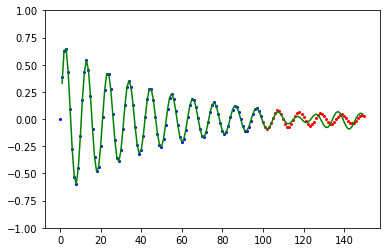

17100 3.321539385885388e-05 0.0010799501107328323


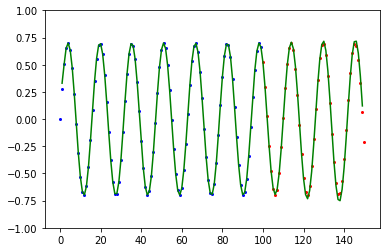

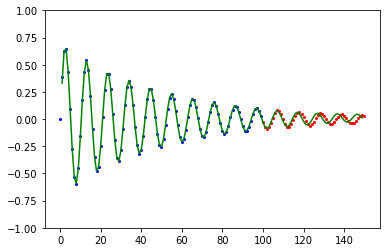

19900 3.369038709989314e-05 0.000516416431003484


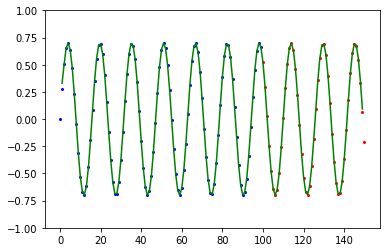

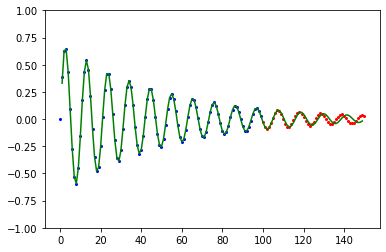

23800 3.377984487224788e-05 0.00038905017537389135


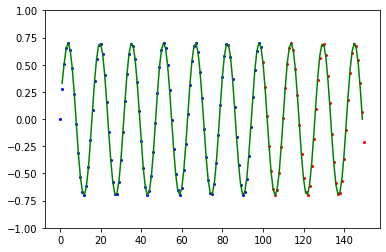

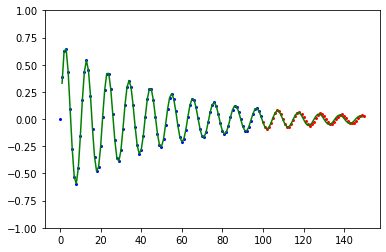

28000 3.357912186449793e-05 0.00014975542557393666


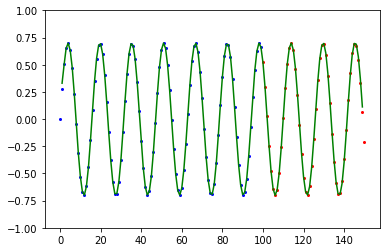

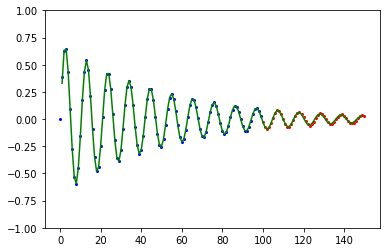

33700 3.3442904094808915e-05 0.0028507563895038054


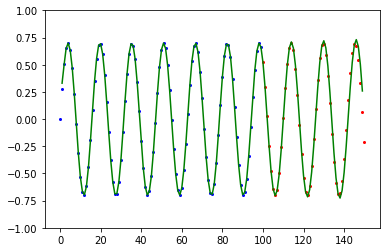

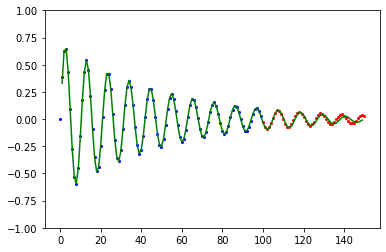

39600 3.316828521410575e-05 0.00015875580855037212


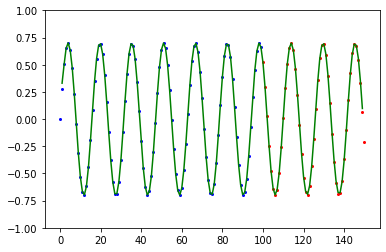

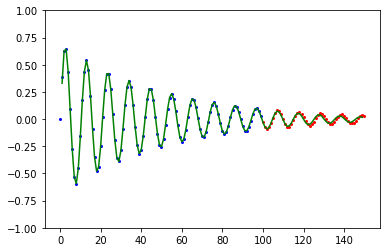

42500 3.32310965769932e-05 3.664730907956206e-05


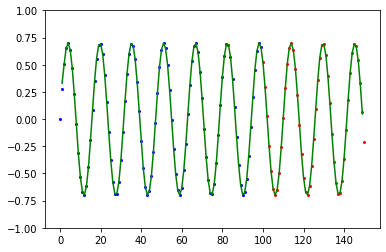

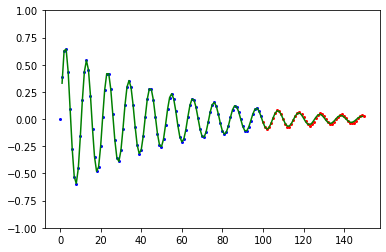

45400 3.3531064904564316e-05 2.7960795150695643e-05


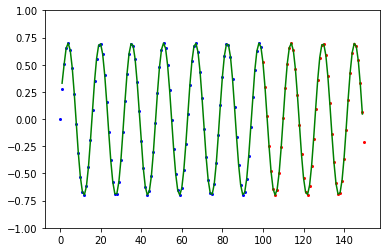

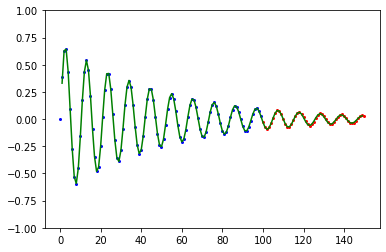

48700 0.009644946372185902 0.0009748267947545052


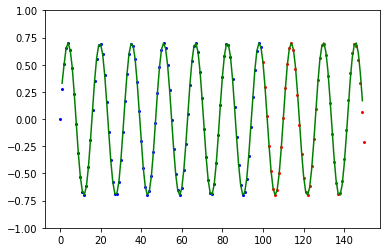

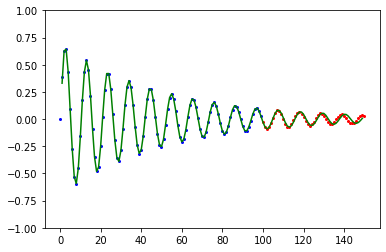

58900 0.059623084478539985 0.10117864878516296


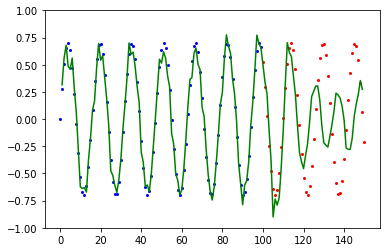

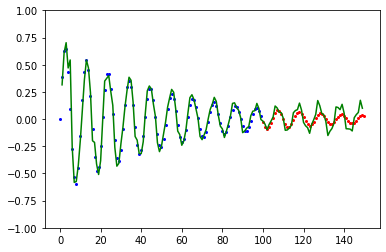

61900 3.4626863585184466e-05 0.004638091682472257


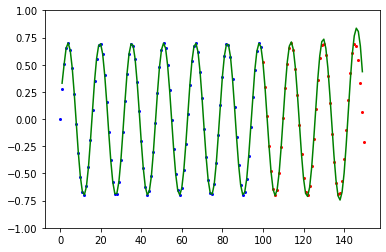

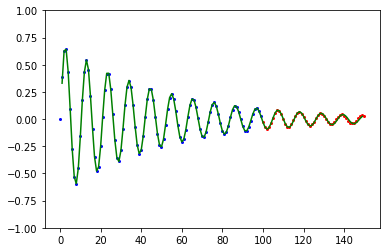

64900 3.323918431570513e-05 7.454230043643821e-05


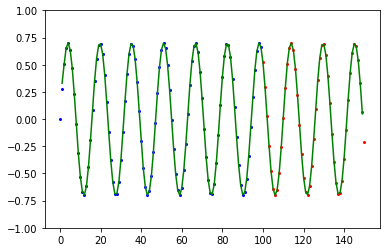

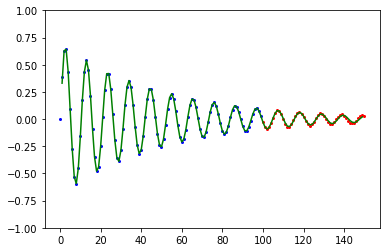

68200 3.352757889838405e-05 0.0006587854884290944


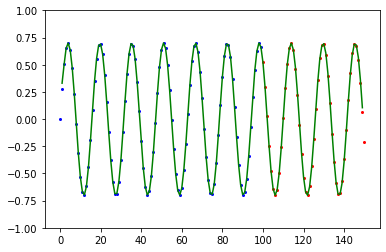

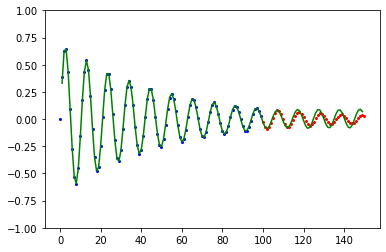

71700 3.379911032846563e-05 0.0007859617984815674


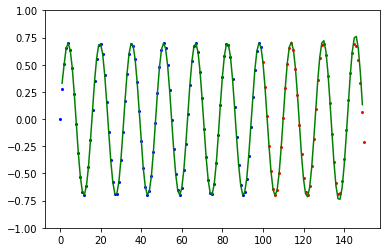

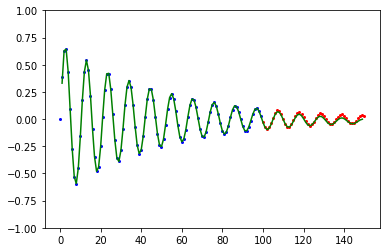

75500 3.320189301829756e-05 0.0006001055556673174


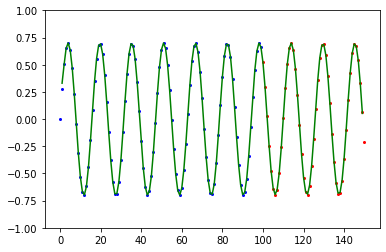

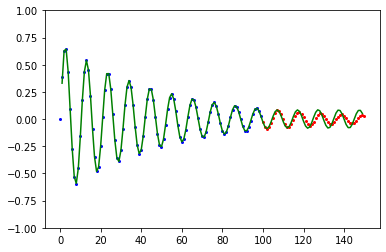

78600 3.3277746339661934e-05 0.001013636617102949


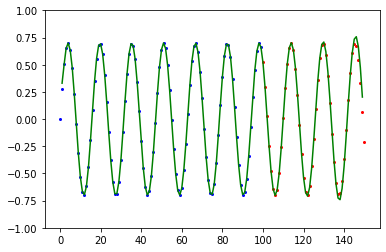

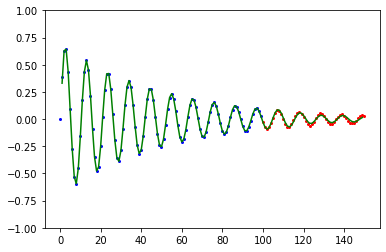

80900 3.350240246405454e-05 0.00030499767875736986


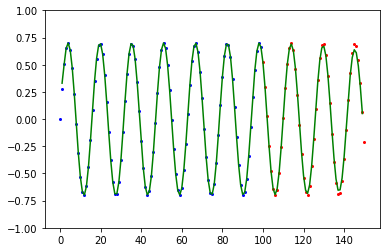

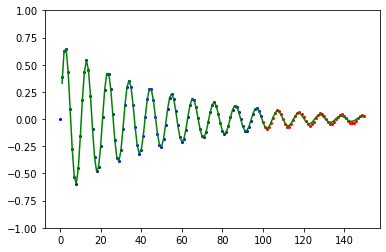

86100 3.3414620763237365e-05 0.0002693290457020688


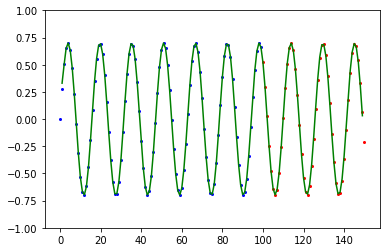

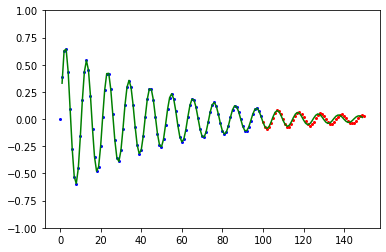

88500 3.3852522092039307e-05 0.0017074446612531495


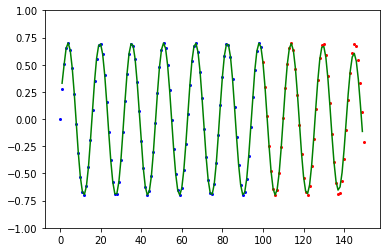

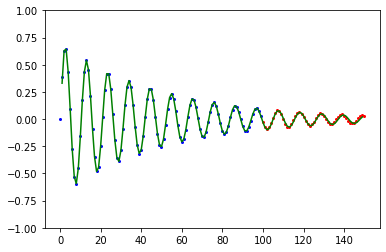

91000 3.3342333762909034e-05 0.00015331127986843685


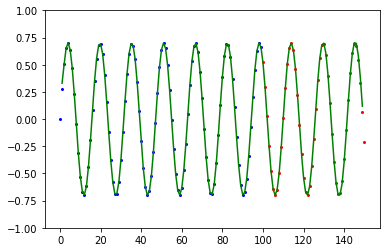

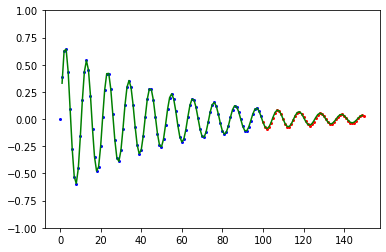

107700 3.334877513186814e-05 0.00020300846692972282


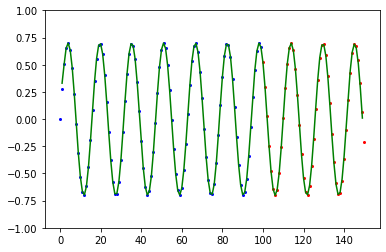

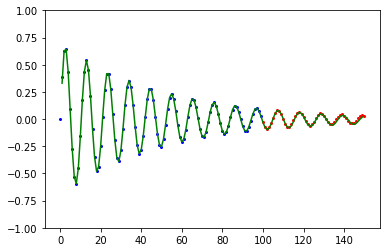

111300 3.352730900751408e-05 3.1570349391862214e-05


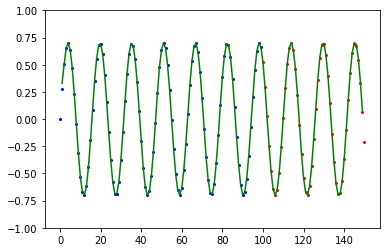

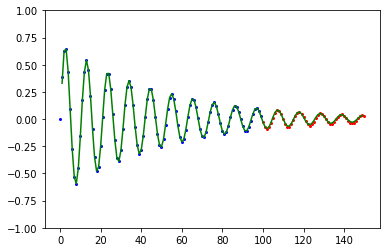

131900 3.9320652528969555e-05 2.214232470094275


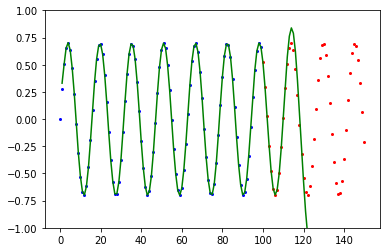

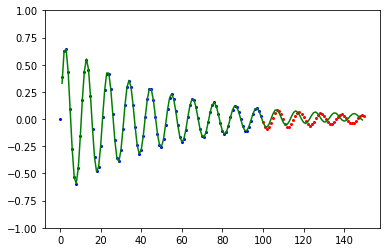

135400 3.333529687151301e-05 0.002210665985951853


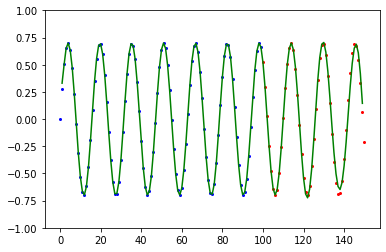

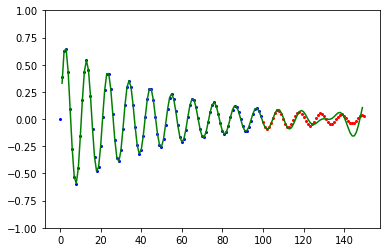

138900 3.338562866463423e-05 7.273524130580722e-05


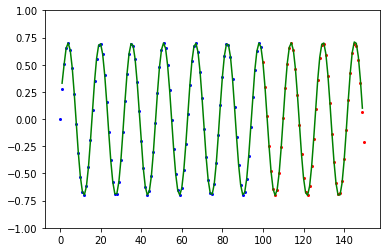

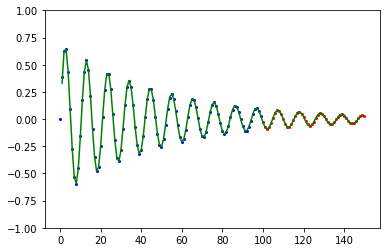

142400 3.371154403607959e-05 7.119165798803553e-05


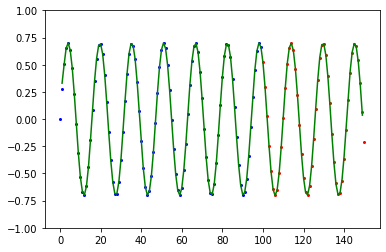

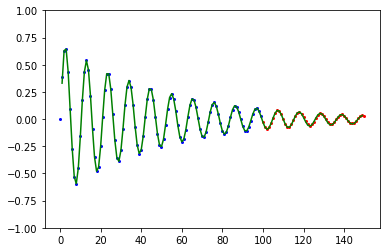

147100 3.334632310454513e-05 0.012618757684253561


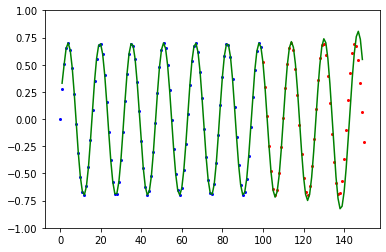

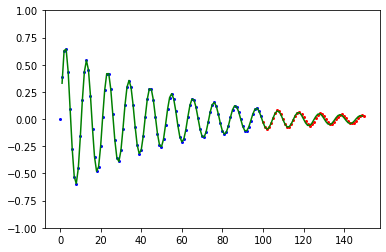

149300 3.334264818124867e-05 0.00014650091989272933


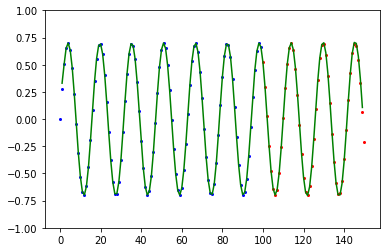

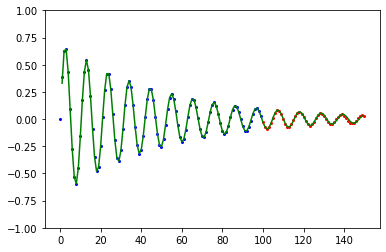

155100 3.308102655580278e-05 0.00018800466922042972


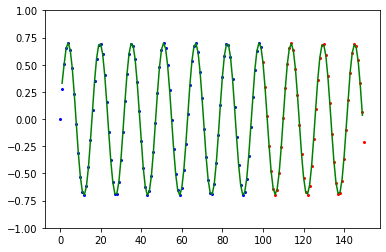

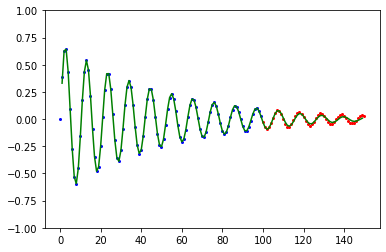

156500 0.01357481848413483 0.04854181519145167


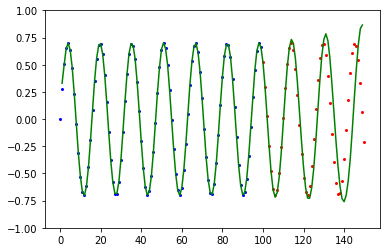

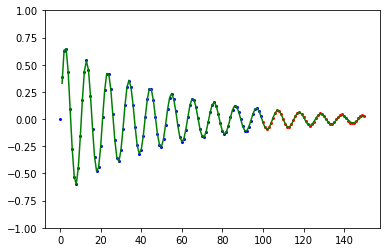

163800 3.464524545207135e-05 0.00012585177900169115


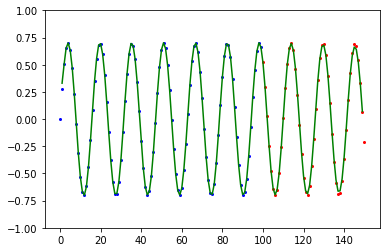

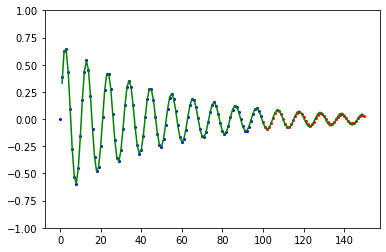

166100 0.02375840467214672 0.006958329382521357


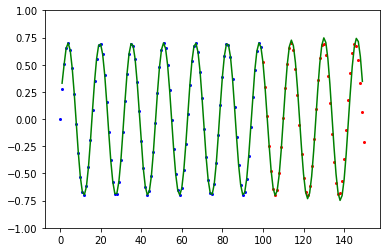

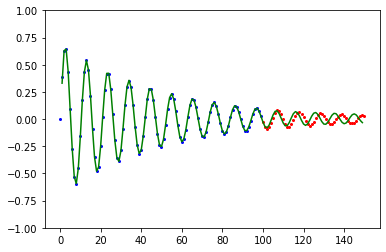

170100 3.3794745128655834e-05 0.00015619831096038835


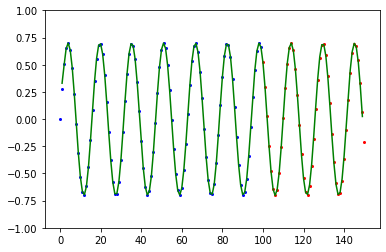

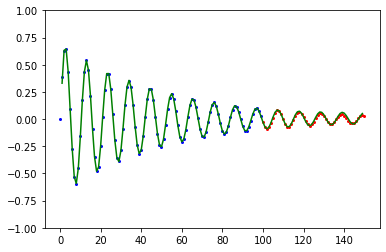

171900 0.034197481894885765 0.12628096978436493


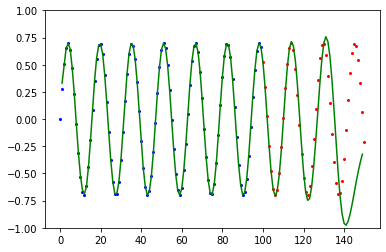

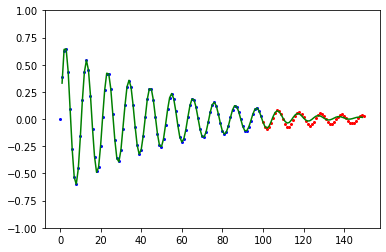

176500 3.337108881614769e-05 0.004643247178208993


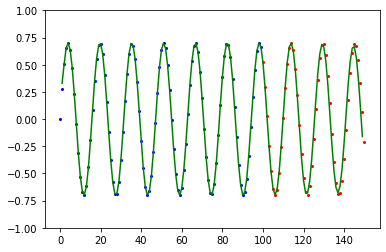

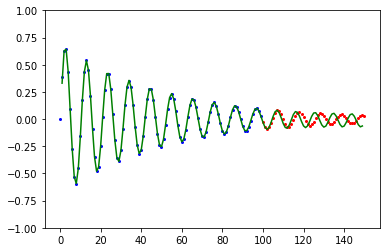

179400 3.369585252551615e-05 0.05242305154525587


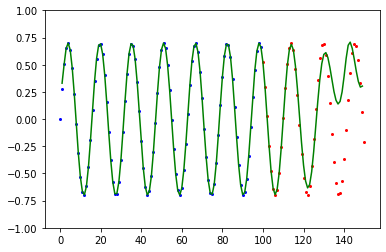

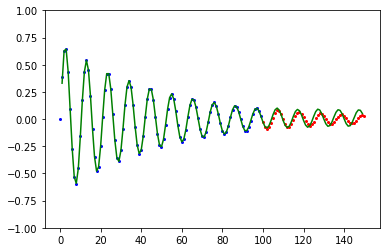

181200 0.049259888465246496 0.4656097868382371


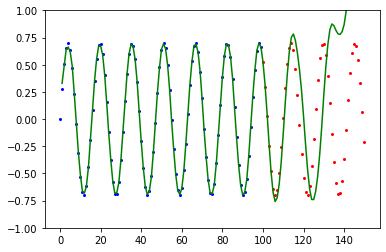

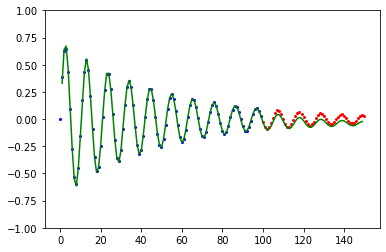

186000 3.410949664648724e-05 0.0011777019632513747


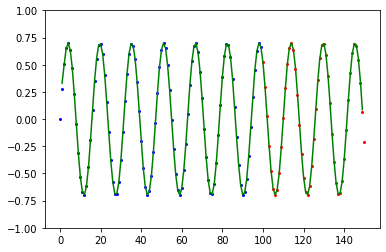

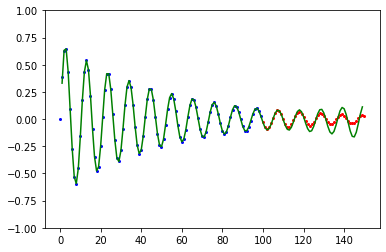

189100 3.377225198046566e-05 0.002175775212187459


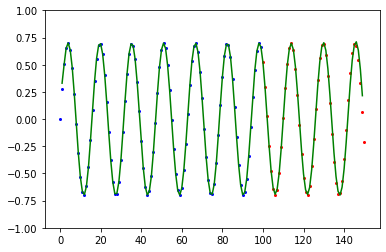

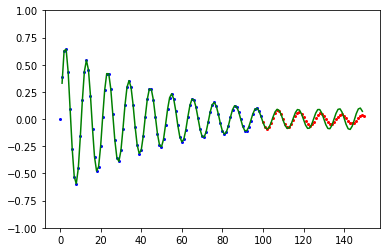

192600 3.341176334143416e-05 0.001485287424721498


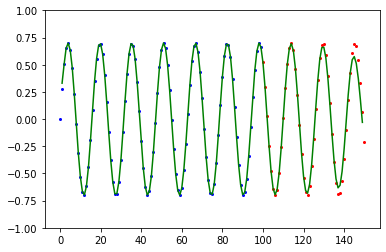

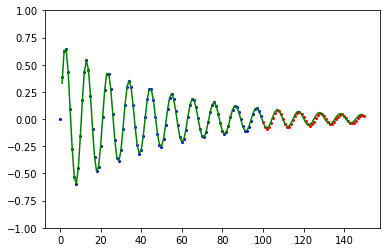

195500 3.3371336139272087e-05 0.04991495779210024


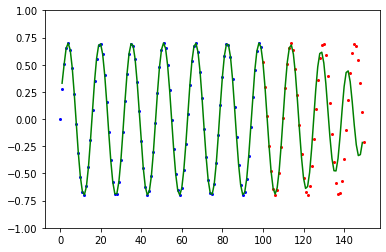

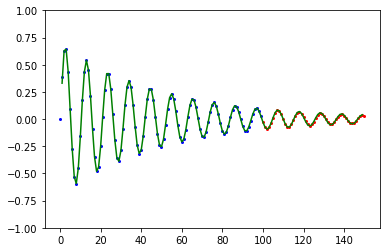

198400 3.346053217913796e-05 0.010208944477028019


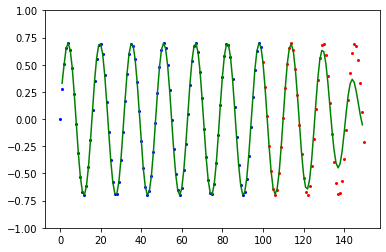

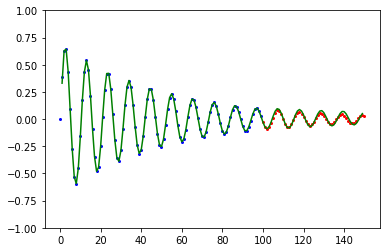

202000 3.337562199875459e-05 0.0005801779879154853


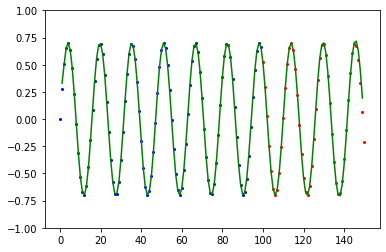

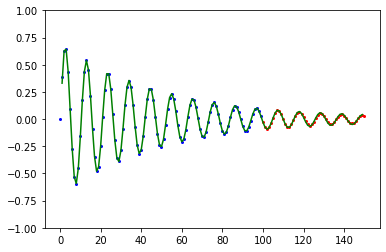

205500 3.367879015219588e-05 0.00017839037215289997


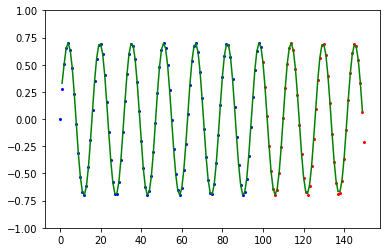

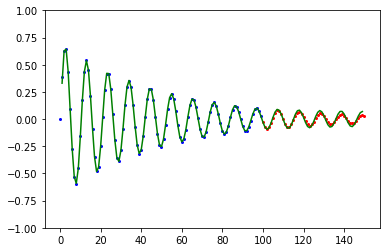

208000 3.331293360263485e-05 0.00027869104279602065


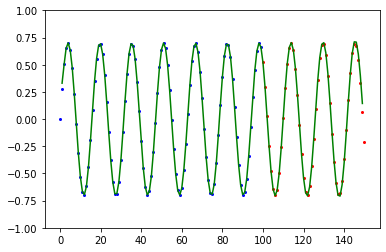

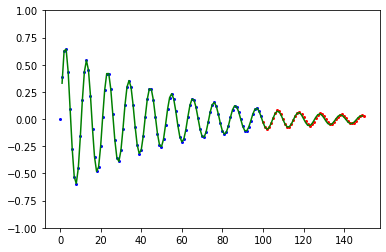

212900 3.328911145103533e-05 0.0007741897529295217


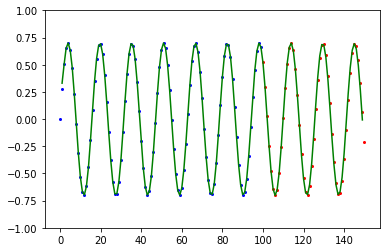

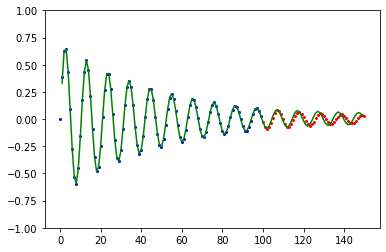

216900 3.360438890236869e-05 0.0007510570259205945


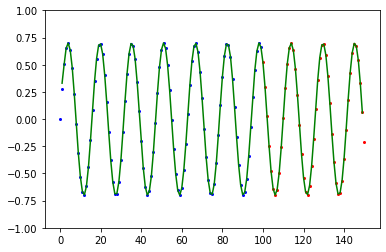

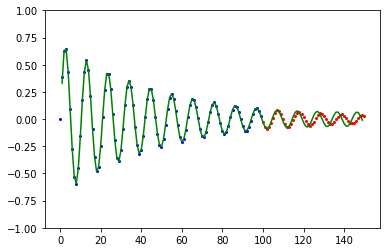

221600 3.315057108169969e-05 0.004713968937796949


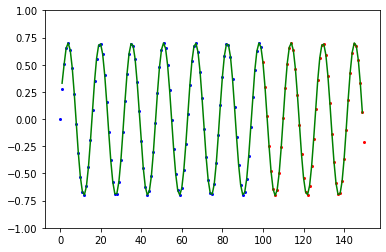

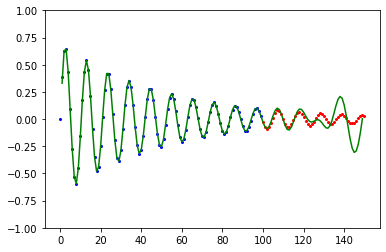

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.06251888, dtype=float64)

In [35]:
len(test_result)

50